In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
original_dataset_dir = r"C:\Users\pk\Desktop\class"

import os

original_dataset_dir = '/content/drive/MyDrive/class'
print("Folder exists?", os.path.exists(original_dataset_dir))
print("Contents:", os.listdir(original_dataset_dir))

classes = os.listdir(original_dataset_dir)
print(classes)

Folder exists? True
Contents: ['Uveal Melanoma (UM)', 'Normal', 'Choroidal Osteoma (CO)', 'Choroidal Hemangioma (CH)']
['Uveal Melanoma (UM)', 'Normal', 'Choroidal Osteoma (CO)', 'Choroidal Hemangioma (CH)']


In [3]:
for cls in classes:
    class_dir = os.path.join(original_dataset_dir, cls)
    num_images = len(os.listdir(class_dir))
    print(f"Class: {cls} --> {num_images} images")

Class: Uveal Melanoma (UM) --> 85 images
Class: Normal --> 1354 images
Class: Choroidal Osteoma (CO) --> 80 images
Class: Choroidal Hemangioma (CH) --> 71 images


In [5]:
import os
import random
import shutil
from sklearn.model_selection import train_test_split

# =========================
# PATH SETTING
# =========================
base_path = "/content/drive/MyDrive/class"

classes = {
    "UM": "Uveal Melanoma (UM)",
    "Normal": "Normal",
    "CO": "Choroidal Osteoma (CO)",
    "CH": "Choroidal Hemangioma (CH)"
}

# =========================
# 1. NORMAL REDUCTION (400)
# =========================
normal_path = os.path.join(base_path, classes["Normal"])
normal_images = os.listdir(normal_path)

selected_normal = random.sample(normal_images, 400)

# =========================
# 2. BUILD DATASET LIST
# =========================
data = []

# Normal (limited)
for img in selected_normal:
    data.append((os.path.join(normal_path, img), "Normal"))

# Other classes (full)
for key, folder in classes.items():
    if key == "Normal":
        continue

    path = os.path.join(base_path, folder)
    for img in os.listdir(path):
        data.append((os.path.join(path, img), key))

# =========================
# 3. SPLIT DATA (STRATIFIED)
# =========================
images, labels = zip(*data)

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# =========================
# 4. CREATE OUTPUT FOLDERS
# =========================
output_dir = "/content/dataset_split"

for split in ["train", "val", "test"]:
    for cls in classes.keys():
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# =========================
# 5. COPY FUNCTION
# =========================
def copy_files(X, y, split):
    for img, label in zip(X, y):
        dst = os.path.join(output_dir, split, label, os.path.basename(img))
        shutil.copy(img, dst)

copy_files(X_train, y_train, "train")
copy_files(X_val, y_val, "val")
copy_files(X_test, y_test, "test")

print(" Dataset split completed successfully!")

 Dataset split completed successfully!


In [6]:
import os

for split in ["train", "val", "test"]:
    print("\n", split)
    for cls in os.listdir(f"/content/dataset_split/{split}"):
        path = f"/content/dataset_split/{split}/{cls}"
        print(cls, len(os.listdir(path)))


 train
CH 50
CO 56
Normal 280
UM 59

 val
CH 10
CO 12
Normal 60
UM 13

 test
CH 11
CO 12
Normal 60
UM 13


In [5]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
    if len(dirs) > 0:
        print("  folders:", dirs)

/content
  folders: ['.config', 'drive', 'sample_data']
/content/.config
  folders: ['logs', 'configurations']
/content/.config/logs
  folders: ['2026.04.16']
/content/.config/logs/2026.04.16
/content/.config/configurations
/content/drive
  folders: ['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']
/content/drive/MyDrive
  folders: ['Colab Notebooks', 'class', 'models_fyp']
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/class
  folders: ['Uveal Melanoma (UM)', 'Normal', 'Choroidal Osteoma (CO)', 'Choroidal Hemangioma (CH)']
/content/drive/MyDrive/class/Uveal Melanoma (UM)
/content/drive/MyDrive/class/Normal
/content/drive/MyDrive/class/Choroidal Osteoma (CO)
/content/drive/MyDrive/class/Choroidal Hemangioma (CH)
/content/drive/MyDrive/models_fyp
/content/drive/.shortcut-targets-by-id
/content/drive/.Trash-0
  folders: ['files', 'info']
/content/drive/.Trash-0/files
/content/drive/.Trash-0/info
/content/drive/.Encrypted
  folders: ['MyDrive', '.shortcut-tar

In [6]:
import os
import shutil
import random

base_dir = "/content/drive/MyDrive/class"
output_dir = "/content/dataset_split"

classes = os.listdir(base_dir)

split = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
}

for s in split:
    for c in classes:
        os.makedirs(f"{output_dir}/{s}/{c}", exist_ok=True)

for c in classes:
    images = os.listdir(f"{base_dir}/{c}")
    random.shuffle(images)

    train_end = int(len(images)*0.7)
    val_end = int(len(images)*0.85)

    for i, img in enumerate(images):
        src = f"{base_dir}/{c}/{img}"

        if i < train_end:
            dst = f"{output_dir}/train/{c}/{img}"
        elif i < val_end:
            dst = f"{output_dir}/val/{c}/{img}"
        else:
            dst = f"{output_dir}/test/{c}/{img}"

        shutil.copy(src, dst)

print("Dataset split completed!")

Dataset split completed!


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 92.5MB/s]


Pretrained VGG16 loaded
Epoch 1/30 | Loss: 12.8884 | Val Acc: 0.0962
Epoch 2/30 | Loss: 6.7418 | Val Acc: 0.1046
Epoch 3/30 | Loss: 3.4427 | Val Acc: 0.1548
Epoch 4/30 | Loss: 1.5819 | Val Acc: 0.1883
Epoch 5/30 | Loss: 1.0522 | Val Acc: 0.3013
Epoch 6/30 | Loss: 0.8700 | Val Acc: 0.5105
Epoch 7/30 | Loss: 0.4110 | Val Acc: 0.5230
Epoch 8/30 | Loss: 0.2060 | Val Acc: 0.5021
Epoch 9/30 | Loss: 0.3386 | Val Acc: 0.6569
Epoch 10/30 | Loss: 0.3448 | Val Acc: 0.5816
Epoch 11/30 | Loss: 0.2544 | Val Acc: 0.6695
Epoch 12/30 | Loss: 0.1107 | Val Acc: 0.7322
Epoch 13/30 | Loss: 0.0853 | Val Acc: 0.7699
Epoch 14/30 | Loss: 0.0677 | Val Acc: 0.8452
Epoch 15/30 | Loss: 0.0542 | Val Acc: 0.8033
Epoch 16/30 | Loss: 0.0504 | Val Acc: 0.7071
Epoch 17/30 | Loss: 0.0476 | Val Acc: 0.8368
Epoch 18/30 | Loss: 0.0388 | Val Acc: 0.7950
Epoch 19/30 | Loss: 0.0313 | Val Acc: 0.7908
Epoch 20/30 | Loss: 0.0199 | Val Acc: 0.8326
Epoch 21/30 | Loss: 0.0149 | Val Acc: 0.8033
Epoch 22/30 | Loss: 0.0222 | Val Acc: 0

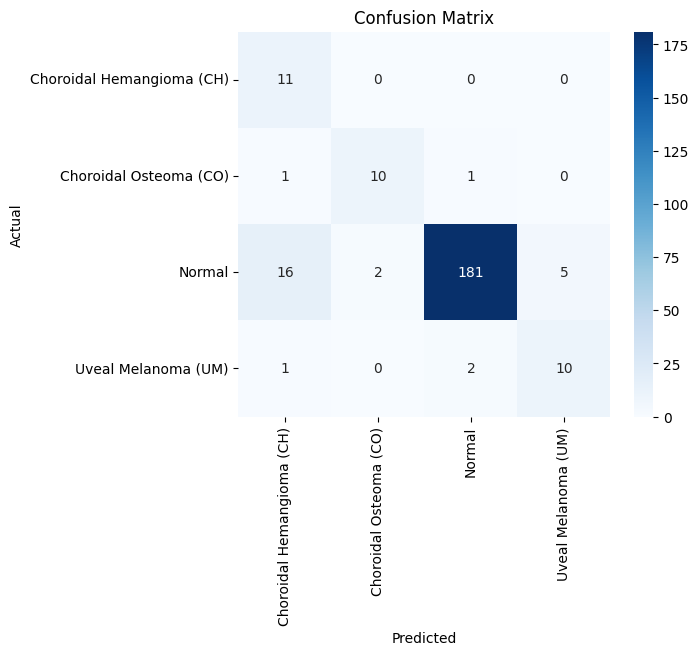

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# STRONG AUGMENTATION (IMPROVED)
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.75,1.0)),
    transforms.RandomAffine(degrees=25, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# =========================
# LOAD DATA
# =========================
train_path = "/content/dataset_split/train"
val_path   = "/content/dataset_split/val"
test_path  = "/content/dataset_split/test"

train_data = datasets.ImageFolder(train_path, transform=train_transform)
val_data   = datasets.ImageFolder(val_path, transform=val_transform)
test_data  = datasets.ImageFolder(test_path, transform=val_transform)

# =========================
# BALANCED SAMPLER
# =========================
class_counts = np.bincount([label for _, label in train_data])
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for _, label in train_data]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

# =========================
# MODEL (VGG16)
# =========================
try:
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    print("Pretrained VGG16 loaded")
except:
    model = models.vgg16(weights=None)
    print("No internet → training from scratch")

# Replace classifier for 4 classes
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 4)

model = model.to(device)

# =========================
# FOCAL LOSS + CLASS WEIGHTS
# =========================
class FocalLoss(nn.Module):
    def __init__(self, gamma=4):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

        weights = torch.tensor([2.0, 2.0, 1.0, 2.5]).to(device)  # CH, CO, Normal, UM
        self.ce = nn.CrossEntropyLoss(weight=weights)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss

criterion = FocalLoss(gamma=4)

# SAME OPTIMIZER (FAIR COMPARISON)
optimizer = optim.Adam(model.parameters(), lr=3e-5)

# =========================
# VALIDATION FUNCTION
# =========================
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

# =========================
# TRAINING (30 EPOCHS)
# =========================
epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pth")

# =========================
# FINAL SAVE
# =========================
torch.save(model.state_dict(), "final_model.pth")
print("Model Saved!")

# =========================
# TEST EVALUATION
# =========================
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# =========================
# REPORT
# =========================
class_names = train_data.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
import os
import random

base_path = "/content/drive/MyDrive/class"   # FIXED

img_paths = []

for cls in os.listdir(base_path):
    folder = os.path.join(base_path, cls)
    if not os.path.isdir(folder):
        continue

    imgs = os.listdir(folder)
    sample = random.sample(imgs, min(5, len(imgs)))

    for img in sample:
        img_paths.append(os.path.join(folder, img))

img_paths = img_paths[:15]

print("Total images:", len(img_paths))

Total images: 15


In [14]:
torch.save(model.state_dict(), "/content/drive/MyDrive/vgg_model.pth")

In [15]:
model = models.vgg16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 4)

model.load_state_dict(torch.load("/content/drive/MyDrive/vgg_model.pth", map_location=device))

<All keys matched successfully>

✔ VGG16 Model Loaded
Total images: 15
Processing 1/15


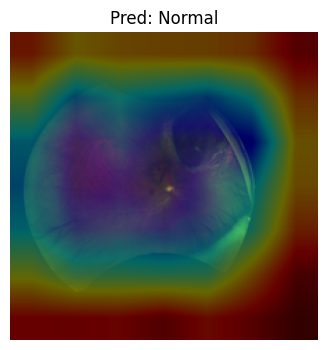

Predicted: Normal
Actual: Uveal Melanoma (UM)
Processing 2/15


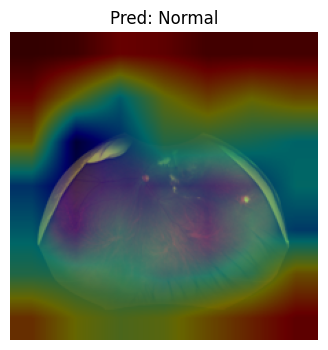

Predicted: Normal
Actual: Uveal Melanoma (UM)
Processing 3/15


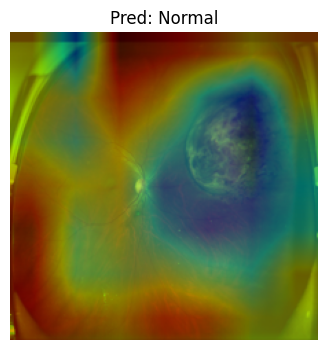

Predicted: Normal
Actual: Uveal Melanoma (UM)
Processing 4/15


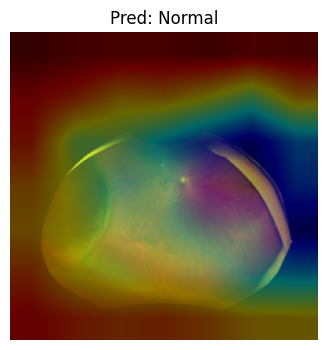

Predicted: Normal
Actual: Uveal Melanoma (UM)
Processing 5/15


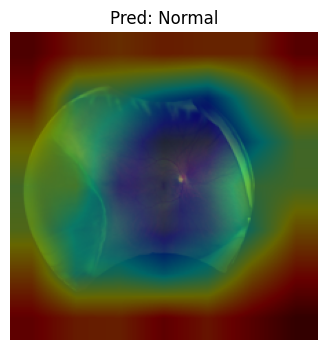

Predicted: Normal
Actual: Uveal Melanoma (UM)
Processing 6/15


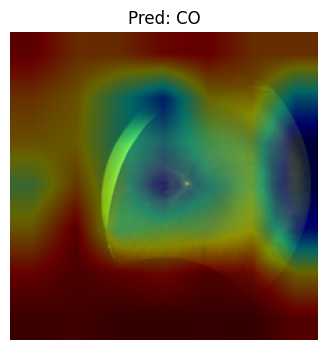

Predicted: CO
Actual: Normal
Processing 7/15


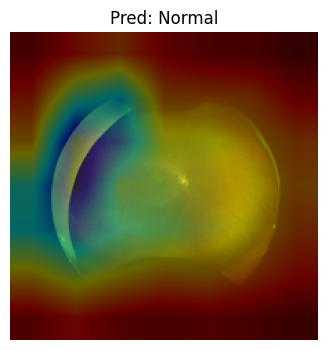

Predicted: Normal
Actual: Normal
Processing 8/15


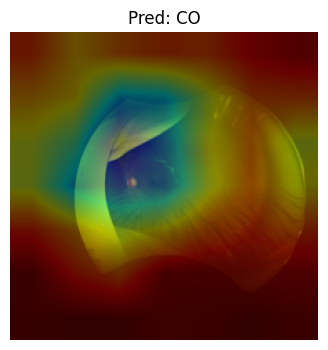

Predicted: CO
Actual: Normal
Processing 9/15


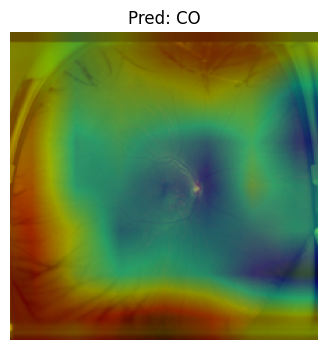

Predicted: CO
Actual: Normal
Processing 10/15


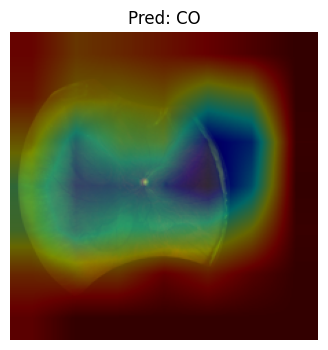

Predicted: CO
Actual: Normal
Processing 11/15


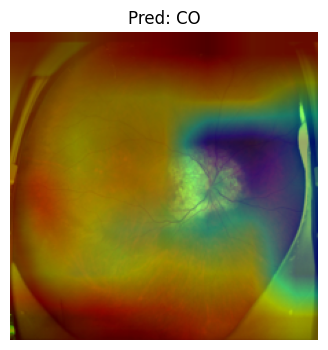

Predicted: CO
Actual: Choroidal Osteoma (CO)
Processing 12/15


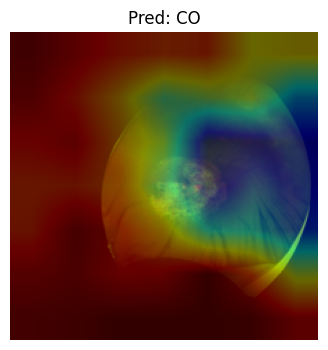

Predicted: CO
Actual: Choroidal Osteoma (CO)
Processing 13/15


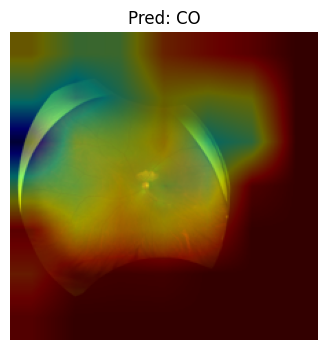

Predicted: CO
Actual: Choroidal Osteoma (CO)
Processing 14/15


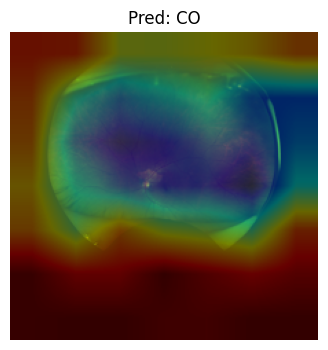

Predicted: CO
Actual: Choroidal Osteoma (CO)
Processing 15/15


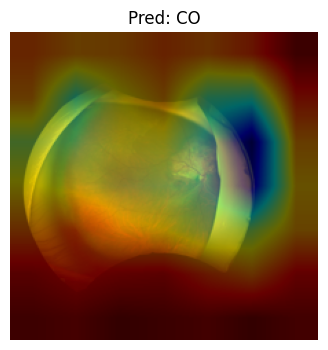

Predicted: CO
Actual: Choroidal Osteoma (CO)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
import shutil
from google.colab import files

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# CLASS NAMES
# =========================
classes = ["CH", "CO", "Normal", "UM"]

# =========================
# MODEL LOAD (VGG16)
# =========================
model = models.vgg16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 4)

model.load_state_dict(torch.load("/content/drive/MyDrive/vgg_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("✔ VGG16 Model Loaded")

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# =========================
# GRAD-CAM CLASS
# =========================
class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.gradients = None
        self.activations = None

        layer.register_forward_hook(self.forward_hook)
        layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, m, i, o):
        self.activations = o

    def backward_hook(self, m, gi, go):
        self.gradients = go[0]

    def generate(self):
        weights = torch.mean(self.gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

# =========================
# VGG16 LAST CONV LAYER
# =========================
gradcam = GradCAM(model, model.features[-1])

# =========================
# DATASET PATH
# =========================
base_path = "/content/drive/MyDrive/class"

img_paths = []

for cls in os.listdir(base_path):
    folder = os.path.join(base_path, cls)
    if not os.path.isdir(folder):
        continue

    imgs = os.listdir(folder)
    sample = random.sample(imgs, min(5, len(imgs)))

    for img in sample:
        img_paths.append(os.path.join(folder, img))

img_paths = img_paths[:15]

print("Total images:", len(img_paths))

# =========================
# OUTPUT DIR
# =========================
save_dir = "/content/gradcam_outputs"
os.makedirs(save_dir, exist_ok=True)

# =========================
# RUN GRAD-CAM
# =========================
for i, path in enumerate(img_paths):

    print(f"Processing {i+1}/15")

    img = Image.open(path).convert("RGB")
    img_resized = img.resize((224,224))

    x = transform(img).unsqueeze(0).to(device)

    # forward
    out = model(x)
    pred = torch.argmax(out, 1)

    # backward
    model.zero_grad()
    out[0, pred].backward()

    # CAM
    cam = gradcam.generate().squeeze().detach().cpu().numpy()

    # heatmap
    heatmap = cv2.resize(cam, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_np = np.array(img_resized)

    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    # SHOW
    plt.figure(figsize=(4,4))
    plt.imshow(overlay)
    plt.title(f"Pred: {classes[pred.item()]}")
    plt.axis("off")
    plt.show()

    print("Predicted:", classes[pred.item()])
    print("Actual:", path.split("/")[-2])

    # SAVE IMAGE
    cv2.imwrite(f"{save_dir}/gradcam_{i+1}.jpg",
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

# =========================
# ZIP + DOWNLOAD
# =========================
zip_path = "/content/gradcam_results"
shutil.make_archive(zip_path, 'zip', save_dir)

files.download(zip_path + ".zip")

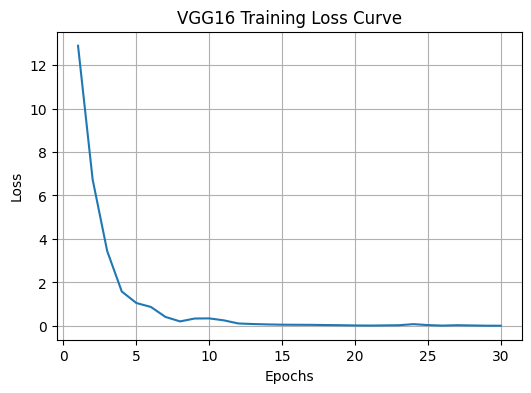

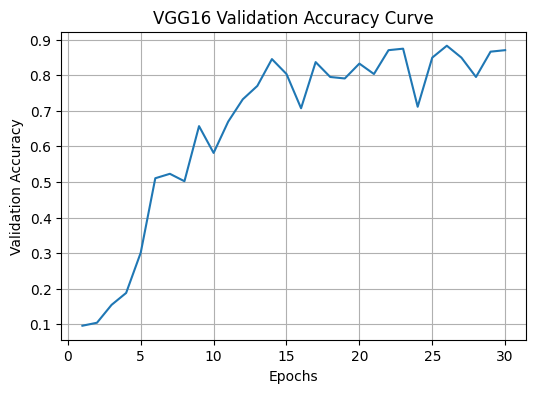

In [17]:
import matplotlib.pyplot as plt

# =========================
# EPOCHS
# =========================
epochs = list(range(1, 31))

# =========================
# LOSS (FROM YOUR LOGS)
# =========================
loss = [
    12.8884, 6.7418, 3.4427, 1.5819, 1.0522, 0.8700, 0.4110, 0.2060, 0.3386, 0.3448,
    0.2544, 0.1107, 0.0853, 0.0677, 0.0542, 0.0504, 0.0476, 0.0388, 0.0313, 0.0199,
    0.0149, 0.0222, 0.0297, 0.0794, 0.0370, 0.0129, 0.0302, 0.0199, 0.0092, 0.0074
]

# =========================
# VALIDATION ACCURACY
# =========================
val_acc = [
    0.0962, 0.1046, 0.1548, 0.1883, 0.3013, 0.5105, 0.5230, 0.5021, 0.6569, 0.5816,
    0.6695, 0.7322, 0.7699, 0.8452, 0.8033, 0.7071, 0.8368, 0.7950, 0.7908, 0.8326,
    0.8033, 0.8703, 0.8745, 0.7113, 0.8494, 0.8828, 0.8494, 0.7950, 0.8661, 0.8703
]

# =========================
# LOSS CURVE
# =========================
plt.figure(figsize=(6,4))
plt.plot(epochs, loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("VGG16 Training Loss Curve")
plt.grid(True)
plt.show()

# =========================
# ACCURACY CURVE
# =========================
plt.figure(figsize=(6,4))
plt.plot(epochs, val_acc)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("VGG16 Validation Accuracy Curve")
plt.grid(True)
plt.show()